# Task 2 -- Edgewise BEMT Formulation (Sec 2.1)

Demonstration of `edgewise_bemt.py` on the actual designed rotor (`task5_tiltrotor_design.TILTROTOR_GEOM` / `TILTROTOR_AIRFOIL`), at a representative low-speed helicopter-mode forward-flight point.

This notebook: (1) solves one edgewise operating point and prints the full summary table, (2) plots blade-element thrust loading at four representative azimuths to make the once-per-rev asymmetry visually obvious, (3) saves the full 2D (r, psi) loading array to CSV for reproducibility.

Formal verification (mu->0 recovery, discretization sensitivity, the full azimuthal contour) is in `task3_verification.ipynb`, not here.

In [1]:
import os
import csv
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from task5_tiltrotor_design import TILTROTOR_GEOM, TILTROTOR_AIRFOIL, RPM_HOVER
from edgewise_bemt import EdgewiseFlightCondition, EdgewiseBEMTSolver

FIG_DIR = "figures"
OUT_DIR = "outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

## Representative operating point

Low-speed helicopter-mode forward flight: hover RPM, a collective that converges cleanly in the M1 axial solver (below theta0~12 deg the underlying bisection fails to bracket a root for this rotor/airfoil combination -- see `dev_notes_bemt_quirks.md` and `task3_verification.ipynb`), and a modest edgewise speed (mu ~ 0.15, well below the mu~0.3-0.5 range where retreating-blade stall/reverse-flow would dominate -- an "early transition" demonstration point, not the edge of the envelope).

In [2]:
COLLECTIVE_DEG = 14.0
V_EDGE_DEMO = 30.0   # [m/s] in-plane speed
V_AXIAL_DEMO = 0.0   # [m/s] level flight, no climb

solver = EdgewiseBEMTSolver(TILTROTOR_GEOM, TILTROTOR_AIRFOIL)
flight = EdgewiseFlightCondition.from_rpm(RPM_HOVER, COLLECTIVE_DEG,
                                          V_axial=V_AXIAL_DEMO, V_edge=V_EDGE_DEMO)
res = solver.solve(flight)

## Summary

In [3]:
print(f"Rotor: R={TILTROTOR_GEOM.R:.2f} m, B={TILTROTOR_GEOM.B}, sigma={res['solidity']:.4f}")
print(f"Condition: {flight.rpm:.0f} RPM, theta0={COLLECTIVE_DEG:.1f} deg, "
      f"V_edge={V_EDGE_DEMO:.1f} m/s, V_axial={V_AXIAL_DEMO:.1f} m/s")
print(f"Advance ratio mu = {res['mu']:.4f}")
print(f"Disk-average baseline inflow lambda_bar = {res['lam_bar']:.5f}, "
      f"Glauert azimuthal-correction coefficient k = {res['k']:.4f}")
print()
print(f"T = {res['T']:.1f} N   Q = {res['Q']:.1f} N.m   P = {res['P']/1000:.1f} kW")
print(f"CT = {res['CT']:.5f}   CQ = {res['CQ']:.6f}   CP = {res['CP']:.6f}")
print(f"Reverse-flow fraction of disk = {res['reverse_flow_fraction']*100:.2f}%")
print(f"Stall fraction = {res['stall_fraction']*100:.2f}%")
print(f"Advancing-tip Mach number = {res['M_adv_tip']:.3f} (hover tip Mach {res['M_tip']:.3f})")
print(f"Rigid-hub 1/rev moments (no flapping): "
      f"M_pitch = {res['hub_pitch_moment']:.1f} N.m, M_roll = {res['hub_roll_moment']:.1f} N.m")

Rotor: R=2.60 m, B=3, sigma=0.0973
Condition: 750 RPM, theta0=14.0 deg, V_edge=30.0 m/s, V_axial=0.0 m/s
Advance ratio mu = 0.1469
Disk-average baseline inflow lambda_bar = 0.04193, Glauert azimuthal-correction coefficient k = 0.9932

T = 4248.1 N   Q = 657.0 N.m   P = 51.6 kW
CT = 0.00392   CQ = 0.000233   CP = 0.000233
Reverse-flow fraction of disk = 0.12%
Stall fraction = 2.15%
Advancing-tip Mach number = 0.688 (hover tip Mach 0.600)
Rigid-hub 1/rev moments (no flapping): M_pitch = -4128.4 N.m, M_roll = 2759.4 N.m


## Sec 2.1 figure: radial loading at four representative azimuths

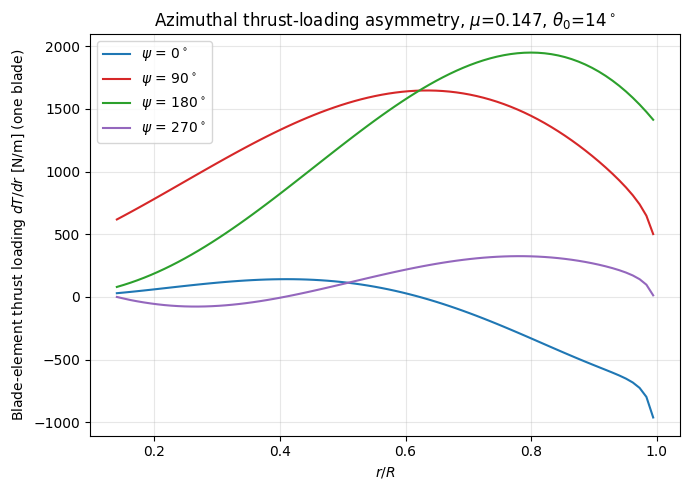

In [4]:
r_over_R = res["r_over_R"]
psi_deg_targets = [0, 90, 180, 270]
plt.figure(figsize=(7, 5))
colors = ["tab:blue", "tab:red", "tab:green", "tab:purple"]
for psi_t, color in zip(psi_deg_targets, colors):
    j = int(np.argmin(np.abs(np.degrees(res["psi"]) - psi_t)))
    plt.plot(r_over_R, res["dT_blade"][:, j], color=color,
             label=f"$\\psi$ = {psi_t}$^\\circ$")
plt.xlabel(r"$r/R$")
plt.ylabel(r"Blade-element thrust loading $dT/dr$ [N/m] (one blade)")
plt.title(f"Azimuthal thrust-loading asymmetry, $\\mu$={res['mu']:.3f}, "
          f"$\\theta_0$={COLLECTIVE_DEG:.0f}$^\\circ$")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task2_1_azimuthal_loading_slices.png"), dpi=160)
plt.show()

## Save full (r, psi) loading table for reproducibility

In [5]:
def save_azimuthal_csv(res, path):
    r, psi = res["r"], res["psi"]
    with open(path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["r_m"] + [f"psi_{np.degrees(p):.1f}deg" for p in psi])
        for i in range(len(r)):
            writer.writerow([r[i]] + list(res["dT_blade"][i, :]))

save_azimuthal_csv(res, os.path.join(OUT_DIR, "task2_1_azimuthal_loading.csv"))
print(f"Full (r,psi) loading table written to ./{OUT_DIR}/task2_1_azimuthal_loading.csv")

Full (r,psi) loading table written to ./outputs/task2_1_azimuthal_loading.csv
